## **🧠 Crystal Classification using EfficientNet (CNN)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/crystal_classification/train"
VAL_DIR   = "/content/drive/MyDrive/crystal_classification/val"


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=16,
    class_mode="categorical"
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)


Found 8055 images belonging to 4 classes.
Found 2011 images belonging to 4 classes.


In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # first stage (important)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(train_gen.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
print(train_gen.class_indices)


{'CaOx_Dihydrate': 0, 'CaOx_Monohydrate_Ovoid': 1, 'Phosphate': 2, 'Uric_Acid': 3}


In [ ]:
import collections

counter = collections.Counter(train_gen.classes)
print(counter)


Counter({np.int32(2): 4414, np.int32(3): 2338, np.int32(0): 1012, np.int32(1): 291})


In [ ]:
train_gen.class_indices


{'CaOx_Dihydrate': 0,
 'CaOx_Monohydrate_Ovoid': 1,
 'Phosphate': 2,
 'Uric_Acid': 3}

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(1.9898715415019763), 1: np.float64(6.920103092783505), 2: np.float64(0.45621884911644767), 3: np.float64(0.8613130881094953)}


In [ ]:
import collections

print(f"\n--- Training Data Counts ---")
print(f"Total images in TRAIN_DIR: {train_gen.n}")
print(f"Class indices: {train_gen.class_indices}")
train_class_counts = collections.Counter(train_gen.classes)
print(f"Class-wise counts in TRAIN_DIR: {train_class_counts}")

print(f"\n--- Validation Data Counts ---")
print(f"Total images in VAL_DIR: {val_gen.n}")
print(f"Class indices: {val_gen.class_indices}")
val_class_counts = collections.Counter(val_gen.classes)
print(f"Class-wise counts in VAL_DIR: {val_class_counts}")


--- Training Data Counts ---
Total images in TRAIN_DIR: 8055
Class indices: {'CaOx_Dihydrate': 0, 'CaOx_Monohydrate_Ovoid': 1, 'Phosphate': 2, 'Uric_Acid': 3}
Class-wise counts in TRAIN_DIR: Counter({np.int32(2): 4414, np.int32(3): 2338, np.int32(0): 1012, np.int32(1): 291})

--- Validation Data Counts ---
Total images in VAL_DIR: 2011
Class indices: {'CaOx_Dihydrate': 0, 'CaOx_Monohydrate_Ovoid': 1, 'Phosphate': 2, 'Uric_Acid': 3}
Class-wise counts in VAL_DIR: Counter({np.int32(2): 1103, np.int32(3): 584, np.int32(0): 252, np.int32(1): 72})


In [ ]:
!pip install ipywidgets


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from ipywidgets import Button, HBox, VBox
from IPython.display import display, clear_output


In [ ]:
BASE_DIR = "urine-sediments-(crystals)-7"
OUT_DIR = "crystal_cnn_manual"
SPLIT = "train"   # change later to valid / test

CLASS_NAMES = [
    "CaOx_Monohydrate",
    "CaOx_Dihydrate",
    "Phosphate",
    "Uric_Acid"
]

for cls in CLASS_NAMES:
    os.makedirs(f"{OUT_DIR}/{SPLIT}/{cls}", exist_ok=True)


In [ ]:
crops = []

img_dir = f"{BASE_DIR}/{SPLIT}/images"
lbl_dir = f"{BASE_DIR}/{SPLIT}/labels"

for img_name in os.listdir(img_dir):
    img_path = os.path.join(img_dir, img_name)
    lbl_path = os.path.join(lbl_dir, img_name.replace(".jpg", ".txt"))

    if not os.path.exists(lbl_path):
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue

    h, w, _ = img.shape

    with open(lbl_path) as f:
        for i, line in enumerate(f):
            parts = line.strip().split()
            if not parts:
                continue

            # Assuming the format is 'class_id x1 y1 w1 h1 x2 y2 w2 h2 ...'
            # where x, y, w, h are normalized coordinates
            try:
                class_id = int(parts[0]) # Extract the class_id (first element)
                coords_str = parts[1:] # The rest are bounding box coordinates as strings

                # Check if the number of coordinate strings is a multiple of 4
                if len(coords_str) % 4 != 0:
                    print(f"Warning: Skipping malformed line in {lbl_path} (line {i+1}). Expected coordinates to be a multiple of 4 after class_id. Line: {line.strip()}")
                    continue

                coords = [float(p) for p in coords_str]

                # Iterate through the coordinates in chunks of 4 for each bounding box
                for j in range(0, len(coords), 4):
                    x, y, bw, bh = coords[j:j+4]

                    # Convert normalized coordinates to absolute pixel coordinates
                    x1 = int((x - bw/2) * w)
                    y1 = int((y - bh/2) * h)
                    x2 = int((x + bw/2) * w)
                    y2 = int((y + bh/2) * h)

                    # Ensure coordinates are within image bounds
                    x1 = max(0, x1)
                    y1 = max(0, y1)
                    x2 = min(w, x2)
                    y2 = min(h, y2)

                    # Check for valid crop dimensions
                    if x1 < x2 and y1 < y2:
                        crop = img[y1:y2, x1:x2]

                        if crop.size > 0:
                            # Use a unique identifier for each crop (line index_bbox_index_on_line)
                            crops.append((crop, img_name, f"{i}_{j//4}"))
                    else:
                        print(f"Warning: Invalid crop dimensions for bbox {j//4} on line {i+1} in {lbl_path}. Calculated: x1={x1}, y1={y1}, x2={x2}, y2={y2}. Skipping crop.")

            except ValueError as e:
                print(f"Error parsing line in {lbl_path} (line {i+1}): {e}. Line content: {line.strip()}")
                continue
            except IndexError:
                print(f"Error: Not enough parts in line in {lbl_path} (line {i+1}). Line content: {line.strip()}")
                continue

print(f"Total crops loaded: {len(crops)}")

Total crops loaded: 3870


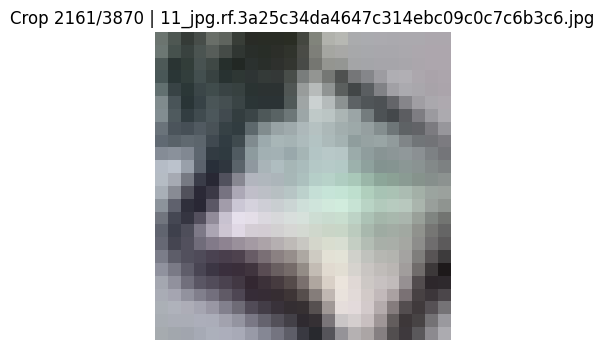

In [ ]:
index = 0

def show_crop():
    clear_output(wait=True)

    if index >= len(crops):
        print("✅ All crops labeled!")
        return

    crop, img_name, i = crops[index]

    plt.figure(figsize=(4,4))
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Crop {index+1}/{len(crops)} | {img_name}")

    display(VBox([
        HBox([btn_mono, btn_di, btn_phos, btn_uric]),
        btn_skip
    ]))

def save_crop(label):
    global index
    crop, img_name, i = crops[index]
    out_path = f"{OUT_DIR}/{SPLIT}/{label}/{img_name.replace('.jpg', f'_{i}.jpg')}"
    cv2.imwrite(out_path, crop)
    index += 1
    show_crop()

def skip_crop(b):
    global index
    index += 1
    show_crop()

btn_mono = Button(description="💎 CaOx Monohydrate", button_style="info")
btn_di = Button(description="🔷 CaOx Dihydrate", button_style="primary")
btn_phos = Button(description="🧪 Phosphate", button_style="success")
btn_uric = Button(description="🟤 Uric Acid", button_style="warning")
btn_skip = Button(description="⏭ Skip", button_style="danger")

btn_mono.on_click(lambda b: save_crop("CaOx_Monohydrate"))
btn_di.on_click(lambda b: save_crop("CaOx_Dihydrate"))
btn_phos.on_click(lambda b: save_crop("Phosphate"))
btn_uric.on_click(lambda b: save_crop("Uric_Acid"))
btn_skip.on_click(skip_crop)

show_crop()


In [ ]:
index += 500

# Ensure index does not exceed the number of crops available
if index >= len(crops):
    index = len(crops) - 1  # Adjust to show the last crop or indicate completion
    if index < 0: # Handle case where there are no crops
        print("No crops to display.")
        index = 0

show_crop()

✅ All crops labeled!


### Saving the `crystal_cnn_manual` folder to Google Drive

This cell will copy the entire `crystal_cnn_manual` directory, containing all the labeled crystal images, into your Google Drive's root `MyDrive` folder. You can change the destination path if you prefer a different location.

In [ ]:
import os

source_folder = "crystal_cnn_manual"
destination_drive_path = "/content/drive/MyDrive/"

# Create the full destination path
destination_folder = os.path.join(destination_drive_path, source_folder)

# Use !cp -r for recursive copy
# You can also use !mv if you want to move it instead of copy
print(f"Copying '{source_folder}' to '{destination_folder}'...")
!cp -r "{source_folder}" "{destination_drive_path}"

print("Copy complete!")
print(f"You can find the folder at: {destination_folder}")

Copying 'crystal_cnn_manual' to '/content/drive/MyDrive/crystal_cnn_manual'...
Copy complete!
You can find the folder at: /content/drive/MyDrive/crystal_cnn_manual


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="JUEYy9YQeALtsxzh563N")
project = rf.workspace("joshua-nogalo-zhweo").project("urine-sediments-crystals")
version = project.version(7)
dataset = version.download("yolov11")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 113.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to urine-sediments-(crystals)-7 in yolov11:: 100%|██████████| 4538/4538 [00:00<00:00, 7847.12it/s]


In [ ]:
import os

save_path = "/content/drive/MyDrive/Urine_Crystal_Datasets/urine_sediments_yolov11"
os.makedirs(save_path, exist_ok=True)


In [ ]:
%cd /content/drive/MyDrive/Urine_Crystal_Datasets


/content/drive/MyDrive/Urine_Crystal_Datasets


In [ ]:
import os

base = "/content/drive/MyDrive/crystal_cnn_manual/train"

for cls in os.listdir(base):
    print(cls, "->", len(os.listdir(os.path.join(base, cls))), "images")


Uric_Acid -> 602 images
CaOx_Dihydrate -> 581 images
Phosphate -> 638 images
CaOx_Monohydrate -> 516 images


In [ ]:
import cv2
import os

bad_images = []

for cls in os.listdir(base):
    cls_path = os.path.join(base, cls)
    for img in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img)
        im = cv2.imread(img_path)
        if im is None:
            bad_images.append(img_path)

print("Broken images:", len(bad_images))


Broken images: 0


In [ ]:
import random

for cls in os.listdir(base):
    cls_path = os.path.join(base, cls)
    img_name = random.choice(os.listdir(cls_path))
    img = cv2.imread(os.path.join(cls_path, img_name))
    print(cls, img.shape)


Uric_Acid (640, 640, 3)
CaOx_Dihydrate (92, 107, 3)
Phosphate (122, 127, 3)
CaOx_Monohydrate (34, 40, 3)


In [ ]:
small = 0

for cls in os.listdir(base):
    for img in os.listdir(os.path.join(base, cls)):
        im = cv2.imread(os.path.join(base, cls, img))
        h, w, _ = im.shape
        if h < 32 or w < 32:
            small += 1

print("Too small images:", small)


Too small images: 62


In [ ]:
import pandas as pd

counts = {}
for cls in os.listdir(base):
    counts[cls] = len(os.listdir(os.path.join(base, cls)))

pd.DataFrame.from_dict(counts, orient="index", columns=["Image Count"])


,Image Count
Uric_Acid,602
CaOx_Dihydrate,581
Phosphate,638
CaOx_Monohydrate,516


from matplotlib import pyplot as plt
_df_2['Image Count'].plot(kind='hist', bins=20, title='Image Count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['Image Count'].plot(kind='line', figsize=(8, 4), title='Image Count')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
import os
import cv2

BASE = "/content/drive/MyDrive/crystal_cnn_manual/train"
MIN_SIZE = 32

removed = 0

for cls in os.listdir(BASE):
    cls_path = os.path.join(BASE, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            os.remove(img_path)
            removed += 1
            continue

        h, w, _ = img.shape
        if min(h, w) < MIN_SIZE:
            os.remove(img_path)
            removed += 1

print("Removed images:", removed)


Removed images: 62


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

BASE = "/content/drive/MyDrive/crystal_cnn_manual"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Classes:", train_ds.class_names)


Found 2275 files belonging to 4 classes.
Classes: ['CaOx_Dihydrate', 'CaOx_Monohydrate', 'Phosphate', 'Uric_Acid']


In [ ]:
import os

base = "/content/drive/MyDrive/crystal_cnn_manual"
print(os.listdir(base))


['train']


In [ ]:
import os
import shutil
import random

BASE = "/content/drive/MyDrive/crystal_cnn_manual"
TRAIN_DIR = os.path.join(BASE, "train")
VAL_DIR = os.path.join(BASE, "val")
TEST_DIR = os.path.join(BASE, "test")

os.makedirs(VAL_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

for cls in os.listdir(TRAIN_DIR):
    cls_train_path = os.path.join(TRAIN_DIR, cls)
    images = os.listdir(cls_train_path)
    random.shuffle(images)

    n = len(images)
    val_count = int(0.15 * n)
    test_count = int(0.15 * n)

    os.makedirs(os.path.join(VAL_DIR, cls), exist_ok=True)
    os.makedirs(os.path.join(TEST_DIR, cls), exist_ok=True)

    # Move to val
    for img in images[:val_count]:
        shutil.move(
            os.path.join(cls_train_path, img),
            os.path.join(VAL_DIR, cls, img)
        )

    # Move to test
    for img in images[val_count:val_count + test_count]:
        shutil.move(
            os.path.join(cls_train_path, img),
            os.path.join(TEST_DIR, cls, img)
        )

print("✅ Train / Val / Test split completed")


✅ Train / Val / Test split completed


In [ ]:
import os

base = "/content/drive/MyDrive/crystal_cnn_manual"
print(os.listdir(base))


['train', 'val', 'test']


In [ ]:
import tensorflow as tf

BASE = "/content/drive/MyDrive/crystal_cnn_manual"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE}/train",
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE}/val",
    image_size=(224,224),
    batch_size=32
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE}/test",
    image_size=(224,224),
    batch_size=32
)

print("Classes:", train_ds.class_names)


Found 1597 files belonging to 4 classes.
Found 339 files belonging to 4 classes.
Found 339 files belonging to 4 classes.
Classes: ['CaOx_Dihydrate', 'CaOx_Monohydrate', 'Phosphate', 'Uric_Acid']


### ***🚀 EfficientNetB0 Training***

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [ ]:
BASE_DIR = "/content/drive/MyDrive/crystal_cnn_manual"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 4


In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE_DIR}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE_DIR}/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 1597 files belonging to 4 classes.
Found 339 files belonging to 4 classes.
Found 339 files belonging to 4 classes.
Classes: ['CaOx_Dihydrate', 'CaOx_Monohydrate', 'Phosphate', 'Uric_Acid']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])


In [ ]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False   # 🔒 Freeze backbone


In [ ]:
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,815 (15.49 MB)

 Trainable params: 7,684 (30.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_efficientnet_crystals.h5",
        monitor="val_accuracy",
        save_best_only=True
    )
]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [ ]:
BASE_DIR = "/content/drive/MyDrive/crystal_cnn_manual"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 4


In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE_DIR}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE_DIR}/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 1597 files belonging to 4 classes.
Found 339 files belonging to 4 classes.
Found 339 files belonging to 4 classes.
Classes: ['CaOx_Dihydrate', 'CaOx_Monohydrate', 'Phosphate', 'Uric_Acid']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])


In [ ]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False   # 🔒 Freeze backbone


In [ ]:
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,815 (15.49 MB)

 Trainable params: 7,684 (30.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_efficientnet_crystals.h5",
        monitor="val_accuracy",
        save_best_only=True
    )
]


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5692 - loss: 1.1892

50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 179ms/step - accuracy: 0.5727 - loss: 1.1794 - val_accuracy: 0.9440 - val_loss: 0.3557
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9124 - loss: 0.2474

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.9125 - loss: 0.2471 - val_accuracy: 0.9617 - val_loss: 0.2092
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9293 - loss: 0.2025

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.9295 - loss: 0.2021 - val_accuracy: 0.9705 - val_loss: 0.1400
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9498 - loss: 0.1584

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.9498 - loss: 0.1581 - val_accuracy: 0.9735 - val_loss: 0.1006
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9633 - loss: 0.1169

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.9633 - loss: 0.1167 - val_accuracy: 0.9764 - val_loss: 0.0802
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9563 - loss: 0.1238

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.9563 - loss: 0.1236 - val_accuracy: 0.9823 - val_loss: 0.0710
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.9731 - loss: 0.0878 - val_accuracy: 0.9794 - val_loss: 0.0681
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.9614 - loss: 0.1005 - val_accuracy: 0.9794 - val_loss: 0.0606
Epoch 9/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.9689 - loss: 0.0852 - val_accuracy: 0.9823 - val_loss: 0.0536
Epoch 10/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9741 - loss: 0.0753

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.9741 - loss: 0.0753 - val_accuracy: 0.9853 - val_loss: 0.0507
Epoch 11/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9747 - loss: 0.0785

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.9748 - loss: 0.0783 - val_accuracy: 0.9882 - val_loss: 0.0503
Epoch 12/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.9686 - loss: 0.0693 - val_accuracy: 0.9823 - val_loss: 0.0501
Epoch 13/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9855 - loss: 0.0498

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.9854 - loss: 0.0500 - val_accuracy: 0.9912 - val_loss: 0.0407
Epoch 14/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.9771 - loss: 0.0682 - val_accuracy: 0.9823 - val_loss: 0.0497
Epoch 15/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.9730 - loss: 0.0650 - val_accuracy: 0.9823 - val_loss: 0.0542
Epoch 16/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.9842 - loss: 0.0355 - val_accuracy: 0.9853 - val_loss: 0.0459
Epoch 17/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.9793 - loss: 0.0494 - val_accuracy: 0.9853 - val_loss: 0.0458
Epoch 18/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.9787 - loss: 0.0674 - val_accuracy: 0.9853 - val_loss: 0.0423


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9931 - loss: 0.0150
Test Accuracy: 0.9941


In [ ]:
model.save("/content/drive/MyDrive/efficientnet_crystals_best_v2.keras")

In [ ]:
import json

with open("/content/drive/MyDrive/train_history.json", "w") as f:
    json.dump(history.history, f)


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Final Test Accuracy:", test_acc)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.9913 - loss: 0.0254
Final Test Accuracy: 0.991150438785553


In [ ]:
import numpy as np

y_true = np.concatenate([
    y.numpy() for _, y in test_ds
])


In [ ]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)


11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 269ms/step


In [ ]:
print(class_names)

['CaOx_Dihydrate', 'CaOx_Monohydrate', 'Phosphate', 'Uric_Acid']


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)


                  precision    recall  f1-score   support

  CaOx_Dihydrate       0.99      1.00      0.99        85
CaOx_Monohydrate       1.00      0.99      0.99        69
       Phosphate       1.00      0.98      0.99        95
       Uric_Acid       0.98      1.00      0.99        90

        accuracy                           0.99       339
       macro avg       0.99      0.99      0.99       339
    weighted avg       0.99      0.99      0.99       339



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)


[[85  0  0  0]
 [ 1 68  0  0]
 [ 0  0 93  2]
 [ 0  0  0 90]]


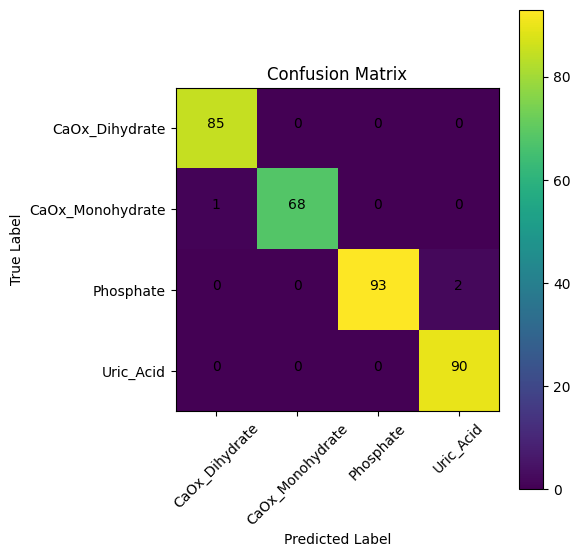

In [ ]:
import matplotlib.pyplot as plt
import itertools

plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [ ]:
last_conv_layer_name = "top_conv"


# **✅ OPTION 1: Upload Image Directly from Laptop**

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/efficientnet_crystals_best"
)

print("✅ Model loaded successfully")


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving uc.jpg to uc (1).jpg


In [ ]:
img_path = list(uploaded.keys())[0]
print("Uploaded image:", img_path)


Uploaded image: uc (1).jpg


In [ ]:
class_names = [
    'CaOx_Dihydrate',
    'CaOx_Monohydrate',
    'Phosphate',
    'Uric_Acid'
]


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)

# Load image
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)

# Expand batch dimension
img_array = np.expand_dims(img_array, axis=0)

# EfficientNet preprocessing
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)


In [ ]:
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions)
confidence = np.max(predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


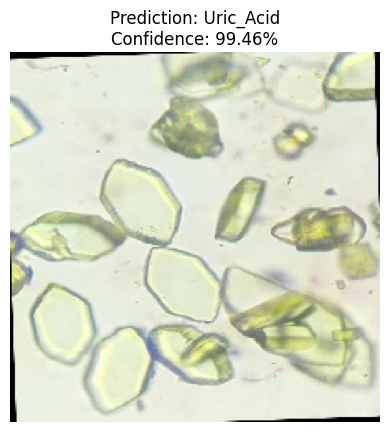

In [ ]:
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {class_names[predicted_class]}\n"
    f"Confidence: {confidence*100:.2f}%"
)
plt.show()


# **🔥Predict multiple local images at once**

In [ ]:
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/efficientnet_crystals_best.keras"
model = tf.keras.models.load_model(MODEL_PATH)

print("✅ Model loaded successfully")


✅ Model loaded successfully


In [ ]:
class_names = [
    "CaOx_Dihydrate",
    "CaOx_Monohydrate",
    "Phosphate",
    "Uric_Acid"
]


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224

def load_and_preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img


In [ ]:
import os

IMAGE_DIR = "/content/local_test_images"

images = []
image_names = []

for img_name in os.listdir(IMAGE_DIR):
    img_path = os.path.join(IMAGE_DIR, img_name)
    if img_name.lower().endswith((".jpg", ".png", ".jpeg")):
        images.append(load_and_preprocess_image(img_path))
        image_names.append(img_name)

images = np.array(images)

pred_probs = model.predict(images)
pred_classes = np.argmax(pred_probs, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
for i, img_name in enumerate(image_names):
    predicted_class = class_names[pred_classes[i]]
    confidence = np.max(pred_probs[i]) * 100

    print(f"{img_name} → {predicted_class} ({confidence:.2f}%)")


B_37f46049.jpg → CaOx_Monohydrate (100.00%)
B_6c3b94c2.jpg → CaOx_Dihydrate (100.00%)
B_370e5727.jpg → Phosphate (99.85%)
1.jpg → Uric_Acid (99.99%)
B_3dafe8eb.jpg → Phosphate (100.00%)
B_4de59a4a.jpg → CaOx_Monohydrate (100.00%)
2.jpg → Uric_Acid (56.29%)
3.jpg → Phosphate (98.66%)


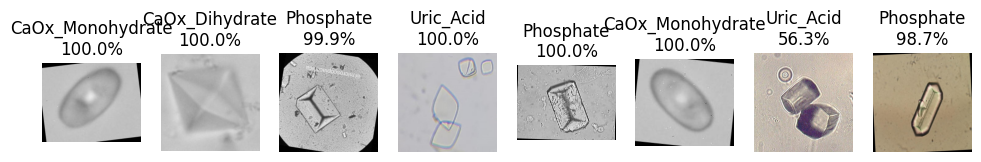

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i, img_name in enumerate(image_names):
    img_path = os.path.join(IMAGE_DIR, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(image_names), i+1)
    plt.imshow(img)
    plt.title(f"{class_names[pred_classes[i]]}\n{np.max(pred_probs[i])*100:.1f}%")
    plt.axis("off")

plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [ ]:
BASE_DIR = "/content/drive/MyDrive/crystal_cnn_manual"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
NUM_CLASSES = 4


In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE_DIR}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE_DIR}/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 1597 files belonging to 4 classes.
Found 339 files belonging to 4 classes.
Found 341 files belonging to 4 classes.
Classes: ['CaOx_Dihydrate', 'CaOx_Monohydrate', 'Phosphate', 'Uric_Acid']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.15),
])


In [ ]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# base_model.trainable = False   # 🔒 Freeze backbone
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False



In [ ]:
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,815 (15.49 MB)

 Trainable params: 2,058,388 (7.85 MB)

 Non-trainable params: 2,001,427 (7.63 MB)

In [ ]:
tf.keras.backend.clear_session()


In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_efficientnet_crystals_v2.keras", # Changed .h5 to .keras
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 193ms/step - accuracy: 0.4754 - loss: 1.5510 - val_accuracy: 0.8643 - val_loss: 0.5570
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.8570 - loss: 0.4140 - val_accuracy: 0.9322 - val_loss: 0.2576
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.9112 - loss: 0.2538 - val_accuracy: 0.9735 - val_loss: 0.1337
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.9210 - loss: 0.2238 - val_accuracy: 0.9764 - val_loss: 0.0903
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.9465 - loss: 0.1456 - val_accuracy: 0.9794 - val_loss: 0.0665
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.9537 - loss: 0.1227 - val_accuracy: 0.9882 - val_loss: 0.0460
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.9708 - loss: 0.0903 - val_accuracy: 0.9853 - val_loss: 0.0398
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.9691 - loss: 0.0875 - val_accuracy: 0

# **🔥Predict multiple local images at once**

In [ ]:
import tensorflow as tf

MODEL_PATH = "/content/best_efficientnet_crystals.keras"
model = tf.keras.models.load_model(MODEL_PATH)

print("✅ Model loaded successfully")


✅ Model loaded successfully


In [ ]:
class_names = [
    "CaOx_Dihydrate",
    "CaOx_Monohydrate",
    "Phosphate",
    "Uric_Acid"
]


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224

def load_and_preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img


In [ ]:
import os

IMAGE_DIR = "/content/local_test_images"

images = []
image_names = []

for img_name in os.listdir(IMAGE_DIR):
    img_path = os.path.join(IMAGE_DIR, img_name)
    if img_name.lower().endswith((".jpg", ".png", ".jpeg")):
        images.append(load_and_preprocess_image(img_path))
        image_names.append(img_name)

images = np.array(images)

pred_probs = model.predict(images)
pred_classes = np.argmax(pred_probs, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
for i, img_name in enumerate(image_names):
    predicted_class = class_names[pred_classes[i]]
    confidence = np.max(pred_probs[i]) * 100

    print(f"{img_name} → {predicted_class} ({confidence:.2f}%)")


B_37f46049.jpg → CaOx_Monohydrate (100.00%)
B_6c3b94c2.jpg → CaOx_Dihydrate (100.00%)
B_370e5727.jpg → Phosphate (98.46%)
1.jpg → Uric_Acid (100.00%)
B_3dafe8eb.jpg → Phosphate (100.00%)
B_4de59a4a.jpg → CaOx_Monohydrate (100.00%)
2.jpg → Uric_Acid (95.86%)
3.jpg → Phosphate (67.18%)


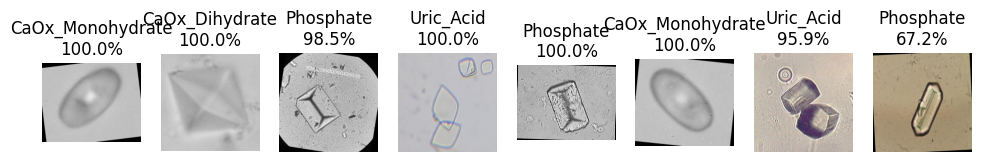

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i, img_name in enumerate(image_names):
    img_path = os.path.join(IMAGE_DIR, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(image_names), i+1)
    plt.imshow(img)
    plt.title(f"{class_names[pred_classes[i]]}\n{np.max(pred_probs[i])*100:.1f}%")
    plt.axis("off")

plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.9931 - loss: 0.0150
Test Accuracy: 0.9941


# **Test 2**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [ ]:
BASE_DIR = "/content/drive/MyDrive/crystal_cnn_manual"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
NUM_CLASSES = 4


In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE_DIR}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE_DIR}/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 1597 files belonging to 4 classes.
Found 339 files belonging to 4 classes.
Found 341 files belonging to 4 classes.
Classes: ['CaOx_Dihydrate', 'CaOx_Monohydrate', 'Phosphate', 'Uric_Acid']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.15),
])


In [ ]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# base_model.trainable = False   # 🔒 Freeze backbone
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False



In [ ]:
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,815 (15.49 MB)

 Trainable params: 2,058,388 (7.85 MB)

 Non-trainable params: 2,001,427 (7.63 MB)

In [ ]:
tf.keras.backend.clear_session()


In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_efficientnet_crystals.h5",
        monitor="val_accuracy",
        save_best_only=True
    )
]


In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_efficientnet_crystals.keras", # Changed .h5 to .keras
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 188ms/step - accuracy: 0.6362 - loss: 1.1533 - val_accuracy: 0.9676 - val_loss: 0.1990
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.9273 - loss: 0.2412 - val_accuracy: 0.9853 - val_loss: 0.0865
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.9571 - loss: 0.1453 - val_accuracy: 0.9912 - val_loss: 0.0485
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.9553 - loss: 0.1036 - val_accuracy: 0.9853 - val_loss: 0.0340
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.9770 - loss: 0.0688 - val_accuracy: 0.9882 - val_loss: 0.0327
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.9738 - loss: 0.0672 - val_accuracy: 0.9882 - val_loss: 0.0244
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.9859 - loss: 0.0403 - val_accuracy: 0.9912 - val_loss: 0.0157
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.9827 - loss: 0.0422 - val_accuracy: 0

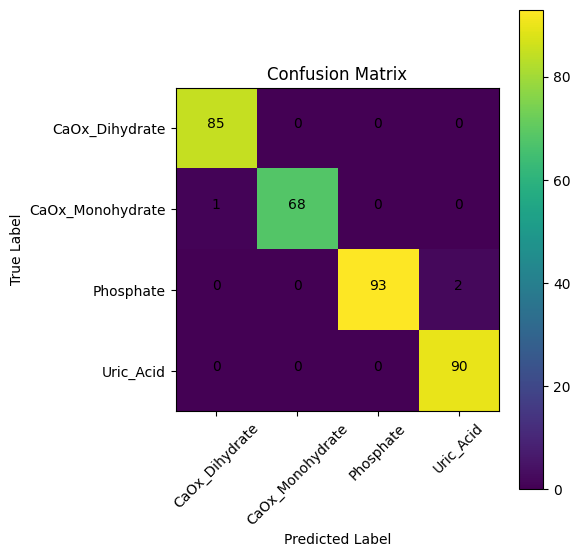

In [ ]:
import matplotlib.pyplot as plt
import itertools

plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


# **🔥Predict multiple local images at once**

In [30]:
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/efficientnet_crystals_best_v2.keras"
model = tf.keras.models.load_model(MODEL_PATH)

print("✅ Model loaded successfully")


✅ Model loaded successfully


In [31]:
class_names = [
    "CaOx_Dihydrate",
    "CaOx_Monohydrate",
    "Phosphate",
    "Uric_Acid"
]


In [32]:
import cv2
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224

def load_and_preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img


In [33]:
import os

IMAGE_DIR = "/content/drive/MyDrive/local_test_images"

images = []
image_names = []

for img_name in os.listdir(IMAGE_DIR):
    img_path = os.path.join(IMAGE_DIR, img_name)
    if img_name.lower().endswith((".jpg", ".png", ".jpeg")):
        images.append(load_and_preprocess_image(img_path))
        image_names.append(img_name)

images = np.array(images)

pred_probs = model.predict(images)
pred_classes = np.argmax(pred_probs, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [34]:
for i, img_name in enumerate(image_names):
    predicted_class = class_names[pred_classes[i]]
    confidence = np.max(pred_probs[i]) * 100

    print(f"{img_name} → {predicted_class} ({confidence:.2f}%)")


B_db844fc5_0_0.jpg → CaOx_Dihydrate (99.91%)
B_4b89d03a_0_1.jpg → CaOx_Dihydrate (99.99%)
B_0f062911.jpg → Phosphate (100.00%)
A_1c3dc9e8_0_0.jpg → Uric_Acid (100.00%)
A_0caef083_0_2.jpg → Uric_Acid (99.98%)
B_64c7fcd4.jpg → Phosphate (100.00%)
B_5b5b6853.jpg → CaOx_Monohydrate (100.00%)
17248786192473912_jpg.rf.f1bbe6c41003335f93081298cdf3bf8e.jpg → Uric_Acid (100.00%)
B_07b7b2e0_0_0.jpg → CaOx_Monohydrate (100.00%)
17247832206788445_jpg.rf.6ae10ba020b719a8e7dd8c8eeedf8c19.jpg → Phosphate (67.18%)
17247832415528533_jpg.rf.6d5a4dc77b54a7682c42900f8014b18d.jpg → Phosphate (99.76%)
17247887689672859_jpg.rf.a36730a56bdd1b604e80a741df1ea911.jpg → CaOx_Dihydrate (64.50%)
172487855815835_jpg.rf.47b864f371da3804577d0289e0d8b82d.jpg → Uric_Acid (100.00%)
17247888034340045_jpg.rf.2f34da6a3c2446b136646f063bd8ba0a.jpg → CaOx_Dihydrate (97.10%)
B_da6fab70.jpg → CaOx_Dihydrate (99.32%)
B_f629bf86.jpg → CaOx_Monohydrate (100.00%)


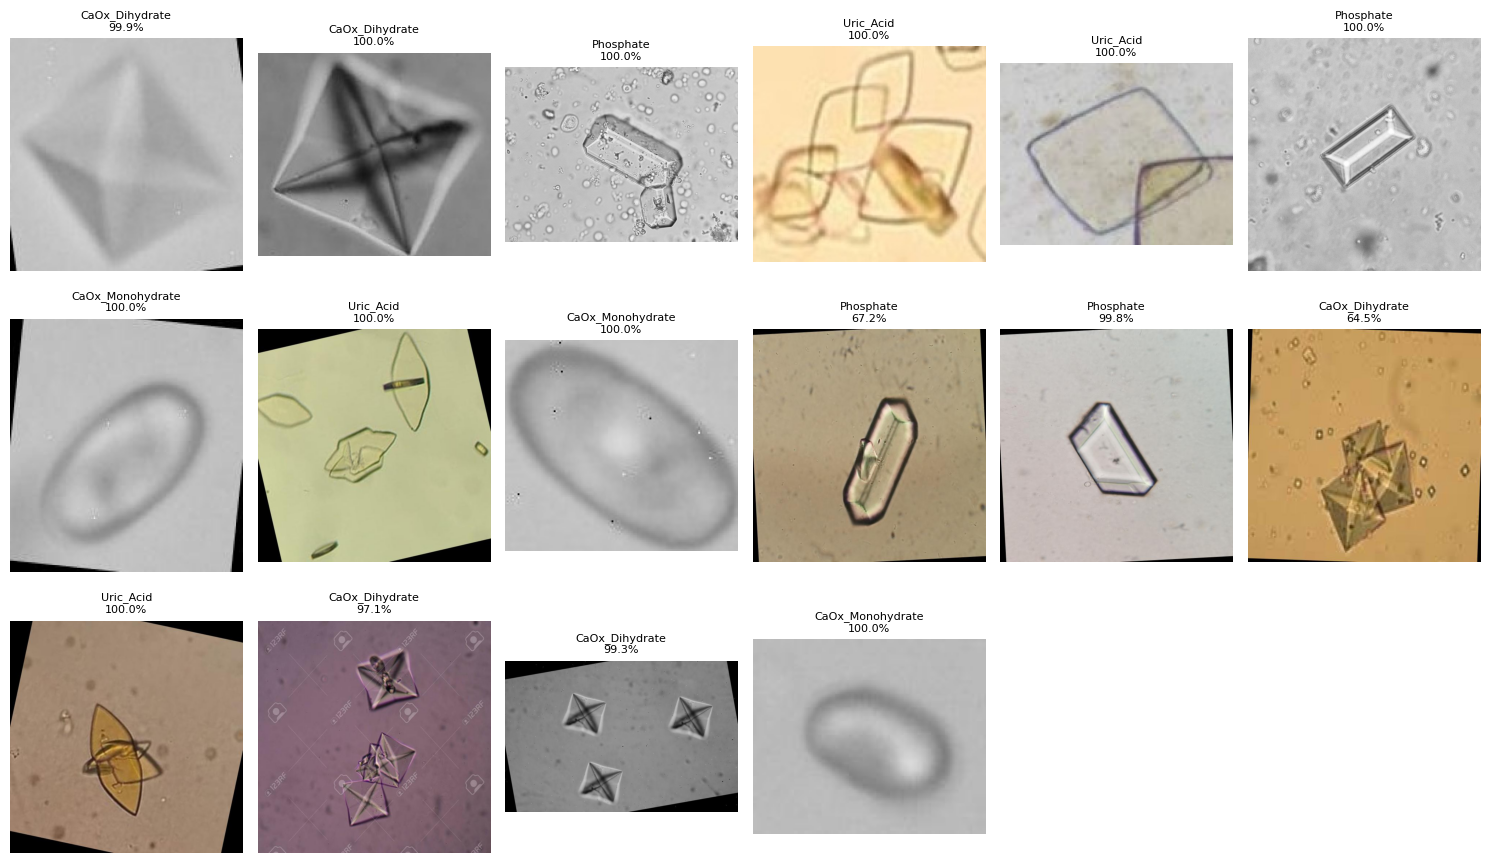

In [35]:
import matplotlib.pyplot as plt
import math

# Set the number of columns
cols = 6
rows = math.ceil(len(image_names) / cols)

plt.figure(figsize=(15, 3 * rows))  # Adjust height based on number of rows

for i, img_name in enumerate(image_names):
    img_path = os.path.join(IMAGE_DIR, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.title(f"{class_names[pred_classes[i]]}\n{np.max(pred_probs[i])*100:.1f}%", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
import tensorflow as tf

# Define paths and parameters
BASE_DIR = "/content/drive/MyDrive/crystal_cnn_manual"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load the test dataset
print("Loading test data...")
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{BASE_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Evaluate the loaded model
print("Evaluating...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

Loading test data...
Found 341 files belonging to 4 classes.
Evaluating...
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.9931 - loss: 0.0150

✅ Test Accuracy: 0.9941
